# LSI — Least Squares Integral

Manual scratchpad for the numeric integral-OLS method (`dt.fit_lsi`,
`method="lsi"`). Plots need the viz extra: `pip install -e '.[viz]'`.
LSI expects a modest argument range (the empirical spectrum is a Maclaurin
fit around 0), so use a normalized / small `x` domain.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dtfit as dt
from dtfit.simulation import apply_normal_noise

dt.enable_logging()  # show INFO logs from the fitters

<Logger dtfit (INFO)>

## Data — exponential decay  y = 2.5·exp(-1.2 x)

In [2]:
x = np.linspace(0, 2, 80)
y_true = 2.5 * np.exp(-1.2 * x)
y = apply_normal_noise(y_true, 0.0, 0.08, seed=0)

## Fit

In [3]:
res = dt.fit_lsi(x, y, "a*exp(b*x)", "x", p0=[1.0, -0.5])
print("coeffs (a, b):", res.coeffs)  # true: 2.5, -1.2

coeffs (a, b): [ 2.53899823 -1.18991157]


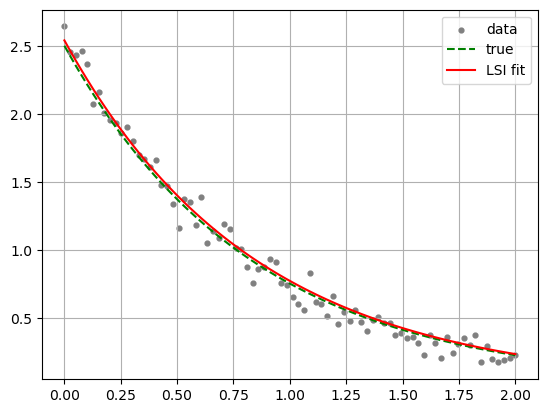

In [4]:
plt.scatter(x, y, s=12, color="gray", label="data")
plt.plot(x, y_true, "g--", label="true")
plt.plot(x, res.model(x), "r-", label="LSI fit")
plt.legend(); plt.grid(True); plt.show()

## Knobs to try
- `k_star` (discretes), `alpha` (weight decay), `filter_data`
- `bounds=[(min,max), ...]` switches on a global search (no good `p0` needed)

In [5]:
res_g = dt.fit_lsi(x, y, "a*exp(b*x)", "x", bounds=[(0, 5), (-3, 0)])
print("global-search coeffs:", res_g.coeffs)

global-search coeffs: [ 2.53899798 -1.18991134]
